In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models

### Load the datasets

In [2]:
DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
TRAIN_DIR = f"{DATA_DIR}\\Train"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = 43
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.10)
])

### Build the CNN

In [5]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    # Data augmentation
    data_augmentation,
    # Normalization
    layers.Rescaling(1./255),
    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### Callback

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [12]:
history = model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stopping, reduce_lr])

Epoch 1/10


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.3121 - loss: 2.3691 - val_accuracy: 0.4830 - val_loss: 1.4353 - learning_rate: 0.0010
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.5137 - loss: 1.4741 - val_accuracy: 0.7203 - val_loss: 0.9649 - learning_rate: 0.0010
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - accuracy: 0.6378 - loss: 1.0645 - val_accuracy: 0.8514 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.7278 - loss: 0.8058 - val_accuracy: 0.9282 - val_loss: 0.3429 - learning_rate: 0.0010
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 69s 70ms/step - accuracy: 0.7849 - loss: 0.6341 - val_accuracy: 0.9606 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 88s 76ms/step - accuracy: 0.8230 - loss: 0.5266 - val_accuracy: 0.9617 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 76s 69ms/step - accuracy: 0.8538 - loss: 0.4415

### Model Evaluation

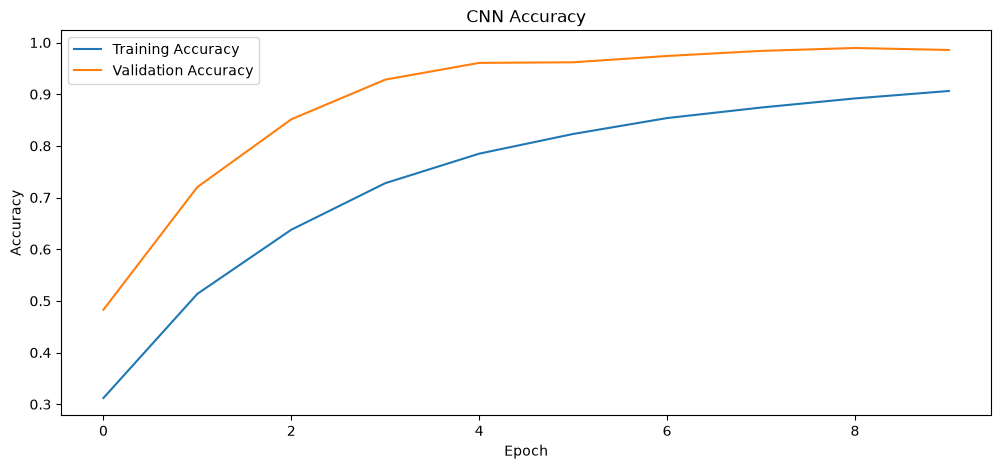

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

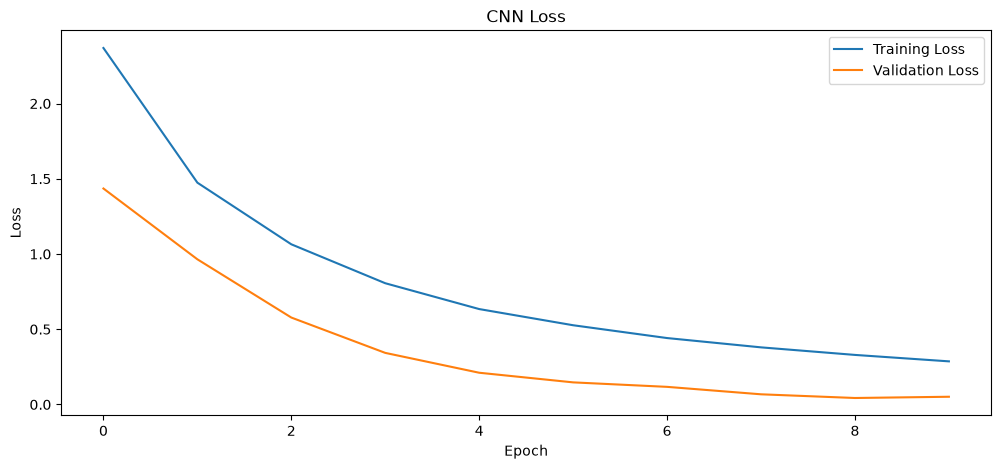

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
print("Unique true labels:", np.unique(y_true))
print("Number of unique true labels:", len(np.unique(y_true)))
print("Unique predicted labels:", np.unique(y_pred))
print("Number of unique predicted labels:", len(np.unique(y_pred)))

Unique true labels: [34 35 36 37 38 39 40 41 42]
Number of unique true labels: 9
Unique predicted labels: [ 2  7  8 12 23 32 34 35 36 37 38 39 40 41 42]
Number of unique predicted labels: 15


In [20]:
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (7841,)
y_pred shape: (7841,)


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False
)
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Classes:", val_ds.class_names)

Found 39209 files belonging to 43 classes.
Using 7841 files for validation.
Validation batches: 246
Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [22]:
y_true = []
y_pred = []
for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("Total validation samples:", len(y_true))
print("Unique true classes:", len(np.unique(y_true)))
print("Unique predicted classes:", len(np.unique(y_pred)))

Total validation samples: 7841
Unique true classes: 9
Unique predicted classes: 15


In [23]:
class_names = val_ds.class_names
report = classification_report(y_true,y_pred,labels=np.arange(NUM_CLASSES),target_names=class_names,digits=4,zero_division=0)
print(report)

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         0
          10     0.0000    0.0000    0.0000         0
          11     0.0000    0.0000    0.0000         0
          12     0.0000    0.0000    0.0000         0
          13     0.0000    0.0000    0.0000         0
          14     0.0000    0.0000    0.0000         0
          15     0.0000    0.0000    0.0000         0
          16     0.0000    0.0000    0.0000         0
          17     0.0000    0.0000    0.0000         0
          18     0.0000    0.0000    0.0000         0
          19     0.0000    0.0000    0.0000         0
           2     0.0000    0.0000    0.0000         0
          20     0.0000    0.0000    0.0000         0
          21     0.0000    0.0000    0.0000         0
          22     0.0000    0.0000    0.0000         0
          23     0.0000    0.0000    0.0000         0
          24     0.0000    

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm,cmap="Blues",annot=False,fmt="d")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()